In [156]:
import gdown
import pandas as pd

gdown.download('https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG', 'train.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1KSQVnefQtRarL-6w5vdd4368hebk3IYG
To: d:\vscode\aiffel\2026\08\26\train.csv
100%|██████████| 648k/648k [00:00<00:00, 3.00MB/s]


'train.csv'

In [157]:
train = pd.read_csv("train.csv") 
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [158]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [159]:
q1 = train['count'].quantile(0.25)
q3 = train['count'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

print(f"25% 지점 (Q1): {q1}")
print(f"75% 지점 (Q3): {q3}")
print(f"IQR (Q3 - Q1): {iqr}")
print(f"이상치 상한선 (Upper Bound): {upper_bound}")

train['count_capped'] = train['count'].apply(lambda x: upper_bound if x > upper_bound else x)

25% 지점 (Q1): 42.0
75% 지점 (Q3): 284.0
IQR (Q3 - Q1): 242.0
이상치 상한선 (Upper Bound): 647.0


상한선을 초과하는 이상치를 상한선 값으로 대체

In [160]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datetime      10886 non-null  datetime64[us]
 1   season        10886 non-null  int64         
 2   holiday       10886 non-null  int64         
 3   workingday    10886 non-null  int64         
 4   weather       10886 non-null  int64         
 5   temp          10886 non-null  float64       
 6   atemp         10886 non-null  float64       
 7   humidity      10886 non-null  int64         
 8   windspeed     10886 non-null  float64       
 9   casual        10886 non-null  int64         
 10  registered    10886 non-null  int64         
 11  count         10886 non-null  int64         
 12  count_capped  10886 non-null  float64       
 13  year          10886 non-null  int32         
 14  month         10886 non-null  int32         
 15  day           10886 non-null  int32         
 1

In [161]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,count_capped,year,month,day,hour,minute,second
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,16.0,2011,1,1,0,0,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,40.0,2011,1,1,1,0,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,32.0,2011,1,1,2,0,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,13.0,2011,1,1,3,0,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1.0,2011,1,1,4,0,0


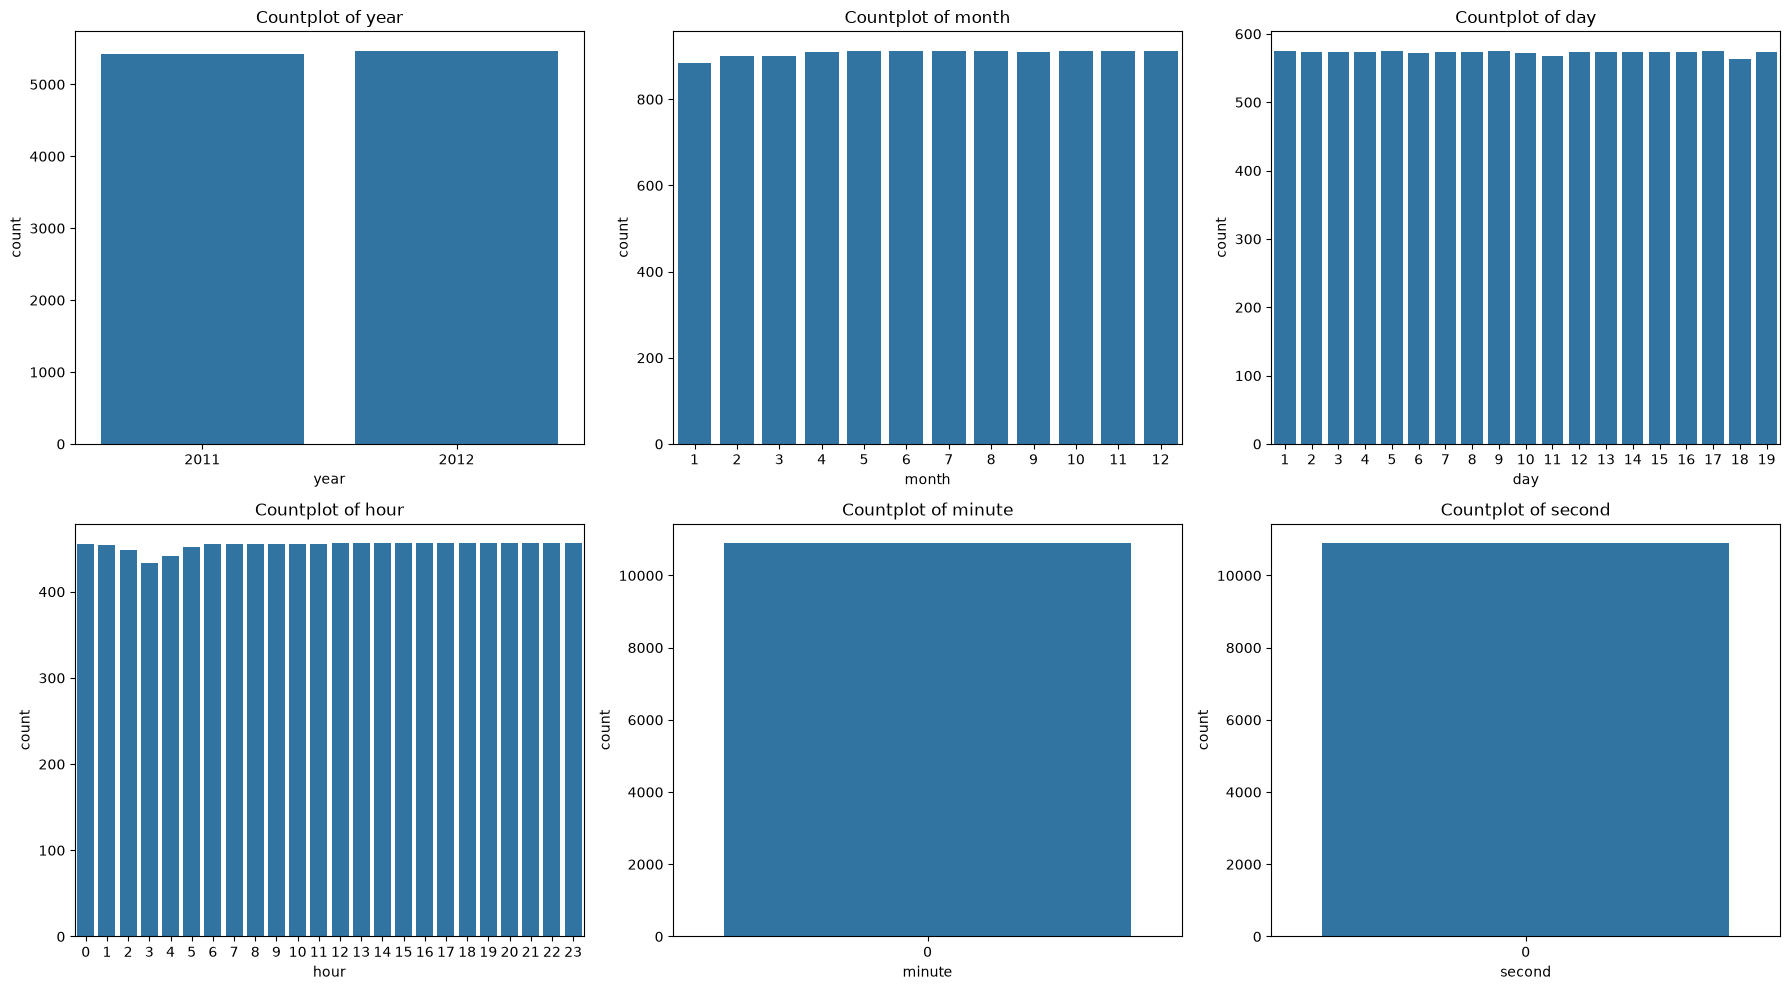

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [163]:
features = ['year', 'month', 'day', 'hour', 'temp', 'humidity', 'windspeed']
X = train[features]
y = train['count_capped']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y = train['count'] -> y = train['count_capped'] 로 변경하여 이상치를 상한선으로 잡은 값으로 변경

In [164]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train);

In [165]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 17591.755468203475
RMSE: 132.63391522609697


y_pred = np.clip(y_pred, 0, None)
코드를 추가하여 음수로 예측한 값은 전부 0 으로 변경

기존에 RMSE는 141대가 찍혔지만

```bash
q1 = train['count'].quantile(0.25)
q3 = train['count'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

train['count_capped'] = train['count'].apply(lambda x: upper_bound if x > upper_bound else x)
```
코드를 추가하여 이상치의 값을 상한선으로 변경 후 변경된 값을 y에 넣어서 확인해보니 RMSE가 133대 까지 떨어졌습니다.
하한선을 넣지 않은 이유는 대여가 음수로 가면 안되기 때문에 하한선은 넣지 않았습니다.

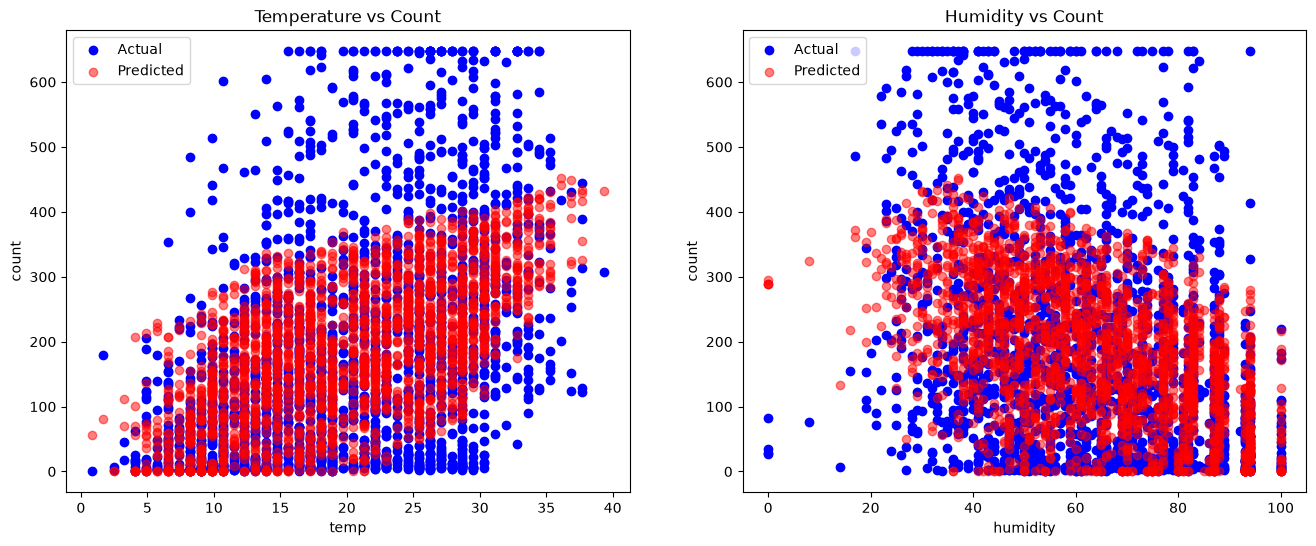

In [166]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

이미 완성된 코드라서 어떤거를 더 추가할지 고민하여 이상치의 값을 상한선으로 고정시켜 141 -> 133 으로 만들었습니다.
이렇게 적용하는 것이 옳게 된 방법인지는 아직 정확하게 확신하지는 못하겠지만
지금 알고 있는 지식으로는 이상치를 활용하여 RMSE의 값을 8대 더 줄였습니다. 

추가로 y_pred = np.clip(y_pred, 0, None) 코드를 추가하여 음수로 예측한 값은 전부 0 으로 변경하여 133 -> 132 로 만들었습니다.